In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from reactiva.config import DATASET_URI
from reactiva.features.build_features import build_features


In [5]:
# ============================================================
# LOAD DATA + SEASON / AGE-GROUP FEATURES + 270-DAY HOLDOUT
# ============================================================

df = pd.read_csv(DATASET_URI)
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df = build_features(df)

MAX_DATE = df['Purchase Date'].max()
CUTOFF = MAX_DATE - pd.Timedelta(days=270)

df_train = df[df['Purchase Date'] < CUTOFF].copy()
df_holdout = df[df['Purchase Date'] >= CUTOFF].copy()

train_seasons = df_train['season'].unique()
train_customers = df_train['Customer ID'].unique()
holdout_customers = df_holdout['Customer ID'].unique()
scoring_customers = np.intersect1d(train_customers, holdout_customers)

print(f'Latest purchase date: {MAX_DATE.date()}')
print(f'Cutoff date: {CUTOFF.date()}')
print(f'Train rows (older than cutoff): {len(df_train)}')
print(f'Holdout rows (last 270 days): {len(df_holdout)}')
print(f'Training seasons available: {sorted(train_seasons)}')
print(f'Scoring customers: {len(scoring_customers)}')


Latest purchase date: 2024-12-30
Cutoff date: 2024-04-04
Train rows (older than cutoff): 6281
Holdout rows (last 270 days): 3719
Training seasons available: ['monsoon', 'post-monsoon', 'summer', 'winter']
Scoring customers: 1877


In [6]:
# ============================================================
# SHARED METRIC HELPERS
# ============================================================

K_DEFAULT = 5


def precision_recall_at_k(recommended, actual, k):
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k:
        return 0.0, 0.0, 0.0

    hits = len(set(rec_k) & actual)
    precision = hits / len(rec_k)
    recall = hits / len(actual) if actual else 0.0
    hit_rate = float(hits > 0)

    return precision, recall, hit_rate


def ndcg_at_k(recommended, actual, k):
    """Binary NDCG@K: correct/relevant items receive relevance=1."""
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k or not actual:
        return 0.0

    dcg = 0.0
    for rank, item in enumerate(rec_k, start=1):
        if item in actual:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(actual), k)
    idcg = sum(
        1.0 / np.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    return dcg / idcg if idcg else 0.0


def average_precision_at_k(recommended, actual, k):
    """Average Precision@K for binary relevance."""
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k or not actual:
        return 0.0

    hits = 0
    precision_sum = 0.0
    seen = set()

    for rank, item in enumerate(rec_k, start=1):
        if item in actual and item not in seen:
            seen.add(item)
            hits += 1
            precision_sum += hits / rank

    return precision_sum / min(len(actual), k) if min(len(actual), k) else 0.0


def long_tail_sets(df_train, cumulative_cutoff=0.8):
    """Define head/tail from training popularity only, avoiding holdout leakage."""
    counts = df_train['Item Purchased'].value_counts()
    cum_share = counts.cumsum() / counts.sum()
    head_items = set(cum_share[cum_share <= cumulative_cutoff].index)

    if not head_items and len(counts):
        head_items = {counts.index[0]}

    tail_items = set(counts.index) - head_items
    return head_items, tail_items


def long_tail_metrics(recommended, actual, tail_items, k):
    """Customer-level long-tail precision/recall/hit rate."""
    rec_k = list(recommended[:k])
    actual_tail = set(actual) & tail_items
    recommended_tail = set(rec_k) & tail_items
    hits = len(recommended_tail & actual_tail)

    # Recall/precision are defined only for customers with relevant tail items
    # when measuring tail performance. Share/coverage are handled separately.
    long_tail_precision = hits / len(recommended_tail) if recommended_tail else 0.0
    long_tail_recall = hits / len(actual_tail) if actual_tail else np.nan
    long_tail_hit_rate = float(hits > 0) if actual_tail else np.nan

    return long_tail_precision, long_tail_recall, long_tail_hit_rate


def get_result_columns(results_df):
    """Resolve recommendation/actual columns while preserving each model's existing names."""
    recommendation_candidates = [
        'recommended', 'Recommendations', 'recommendations'
    ]
    actual_candidates = [
        'actual', 'Actual', 'Actual Items'
    ]

    recommendation_col = next(
        (column for column in recommendation_candidates if column in results_df.columns),
        None
    )
    actual_col = next(
        (column for column in actual_candidates if column in results_df.columns),
        None
    )

    if recommendation_col is None or actual_col is None:
        raise ValueError('Could not identify recommendation/actual columns in results dataframe.')

    return recommendation_col, actual_col


def calculate_all_ranking_and_long_tail_metrics(
    results_df,
    df_train,
    k=5,
    cumulative_cutoff=0.8
):
    """Calculate ranking and long-tail metrics from stored recommendations/actuals."""
    if results_df.empty:
        return {
            'Precision': np.nan,
            'Recall': np.nan,
            'Hit Rate': np.nan,
            'NDCG': np.nan,
            'MAP': np.nan,
            'Long-tail Precision': np.nan,
            'Long-tail Recall': np.nan,
            'Long-tail Hit Rate': np.nan,
            'Long-tail Share': np.nan,
            'Long-tail Catalog Coverage': np.nan
        }

    recommendation_col, actual_col = get_result_columns(results_df)
    _, tail_items = long_tail_sets(
        df_train,
        cumulative_cutoff=cumulative_cutoff
    )

    precision_values = []
    recall_values = []
    hit_values = []
    ndcg_values = []
    map_values = []
    tail_precision_values = []
    tail_recall_values = []
    tail_hit_values = []
    all_recommended_items = []

    for _, row in results_df.iterrows():
        recommended = row[recommendation_col] or []
        actual = row[actual_col] or []

        precision, recall, hit_rate = precision_recall_at_k(
            recommended, actual, k
        )
        precision_values.append(precision)
        recall_values.append(recall)
        hit_values.append(hit_rate)
        ndcg_values.append(ndcg_at_k(recommended, actual, k))
        map_values.append(average_precision_at_k(recommended, actual, k))

        tail_precision, tail_recall, tail_hit = long_tail_metrics(
            recommended, actual, tail_items, k
        )
        tail_precision_values.append(tail_precision)
        tail_recall_values.append(tail_recall)
        tail_hit_values.append(tail_hit)

        all_recommended_items.extend(list(recommended[:k]))

    recommendation_denominator = len(all_recommended_items)
    tail_recommendation_count = sum(
        1 for item in all_recommended_items if item in tail_items
    )
    long_tail_share = (
        tail_recommendation_count / recommendation_denominator
        if recommendation_denominator else 0.0
    )

    distinct_tail_recommended = {
        item for item in all_recommended_items if item in tail_items
    }
    long_tail_catalog_coverage = (
        len(distinct_tail_recommended) / len(tail_items)
        if tail_items else 0.0
    )

    return {
        'Precision': np.mean(precision_values),
        'Recall': np.mean(recall_values),
        'Hit Rate': np.mean(hit_values),
        'NDCG': np.mean(ndcg_values),
        'MAP': np.mean(map_values),
        'Long-tail Precision': np.mean(tail_precision_values),
        'Long-tail Recall': np.nanmean(tail_recall_values),
        'Long-tail Hit Rate': np.nanmean(tail_hit_values),
        'Long-tail Share': long_tail_share,
        'Long-tail Catalog Coverage': long_tail_catalog_coverage
    }


def sparsity_of_matrix(user_item_matrix):
    total_cells = user_item_matrix.size
    if total_cells == 0:
        return np.nan

    nonzero_cells = (user_item_matrix.values > 0).sum()
    return 1 - (nonzero_cells / total_cells)


def get_popularity_scores(df_train):
    counts = df_train['Item Purchased'].value_counts()
    return counts / counts.max()


## Shared Backtesting Framework

All four models are evaluated using the same conceptual three-window timeline:

1. **Training window (`df_train`)** — historical customer behavior used to build the model or customer representation.
2. **Recent window (`df_recent`)** — identifies customers who became inactive and provides current information from customers who are still active.
3. **Future window (`df_future`)** — contains the later purchases of possible-churn customers and is used only as the ground truth for evaluation.

The shared evaluation question is:

> **Can information available before a possible-churn customer returns help predict which items that customer will buy later?**

The same ranking metrics are used for the model comparison, including Precision, Recall, Hit Rate, Long-tail Recall, NDCG, and MAP where available.

# 1. Gradient Boosting Classifier

### What this model does

This model uses each customer's **historical behavior** to predict the **product category** they are most likely to purchase when they return.

It first builds customer-level features from `df_train`, including:

- purchase counts by category,
- total number of purchases,
- recency information such as days since the customer's last purchase.

The model is trained using customers who remain active, with the category observed in `df_recent` used as the prediction target. For each possible-churn customer, the classifier predicts a category. The recommendation list is then created from the most popular items within that predicted category during the recent period.

### Recommendation logic

**Historical customer behavior → predict future category → select popular recent items from that category → recommend Top-K items**

### Role in the comparison

This is a **supervised and personalized model**. Unlike the collaborative filtering models, it does not find similar customers directly. Instead, it learns a relationship between customer features and the category they are likely to purchase.

In [7]:
def build_customer_features_hybrid_gboost(df_train):

    cat_counts = df_train.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Item Purchased',
        aggfunc='count',
        fill_value=0
    )

    cat_counts.columns = [
        f'cat_count_{c}'
        for c in cat_counts.columns
    ]

    agg = df_train.groupby(
        'Customer ID'
    ).agg(
        total_purchases=(
            'Item Purchased',
            'count'
        ),
        last_purchase=(
            'Purchase Date',
            'max'
        )
    )

    reference_date = df_train['Purchase Date'].max()

    agg['days_since_last_purchase'] = (
        reference_date - agg['last_purchase']
    ).dt.days

    agg = agg.drop(
        columns='last_purchase'
    )

    return cat_counts.join(
        agg,
        how='inner'
    )

def backtest_gboost_churn_reactivation(
    df_train,
    df_recent,
    df_future,
    k=5
):

    # --------------------------------------------------------
    # 1. BUILD FEATURES FROM df_train ONLY
    #
    # Computed once, for every customer with history in
    # df_train -- both the ones who stay active and the ones
    # who churn. Nothing from df_recent or df_future goes into
    # these features.
    # --------------------------------------------------------

    features_train = build_customer_features_hybrid_gboost(
        df_train
    )

    # --------------------------------------------------------
    # 2. IDENTIFY ACTIVE VS POSSIBLE-CHURN CUSTOMERS
    #
    # Same definition as the CF backtest: churn = existed in
    # df_train but made no purchase in df_recent.
    # --------------------------------------------------------

    historical_customers = set(
        df_train['Customer ID'].unique()
    )

    active_customers = set(
        df_recent['Customer ID'].unique()
    )

    possible_churn_customers = (
        historical_customers - active_customers
    )

    # --------------------------------------------------------
    # 3. LABELS FOR ACTIVE CUSTOMERS
    #
    # We only know the "true" next-category for customers who
    # DID buy something in df_recent -- i.e. the active ones.
    # This is what the classifier learns from.
    # --------------------------------------------------------

    labels_recent = (
        df_recent
        .groupby('Customer ID')['Category']
        .agg(lambda x: x.mode().iloc[0])
    )

    common_customers = (
        features_train.index.intersection(labels_recent.index)
    )

    X = features_train.loc[common_customers]
    y = labels_recent.loc[common_customers]

    # --------------------------------------------------------
    # 4. TRAIN GBOOST
    # --------------------------------------------------------

    clf = None
    pred_category_churn = pd.Series(dtype=object)

    if len(X) > 0 and y.nunique() > 1:

        class_counts = y.value_counts()
        n_classes = len(class_counts)
        n_samples = len(y)

        class_weights = {
            category: n_samples / (n_classes * count)
            for category, count in class_counts.items()
        }

        sample_weight = y.map(class_weights)

        clf = GradientBoostingClassifier(random_state=42)
        clf.fit(X, y, sample_weight=sample_weight)

        # ------------------------------------------------
        # 5. PREDICT FOR POSSIBLE-CHURN CUSTOMERS
        #
        # Using ONLY their df_train features -- exactly what
        # would be available at the moment they went inactive.
        # ------------------------------------------------

        churn_features = features_train.loc[
            features_train.index.isin(possible_churn_customers)
        ]

        if not churn_features.empty:

            pred_category_churn = pd.Series(
                clf.predict(churn_features),
                index=churn_features.index
            )

    # --------------------------------------------------------
    # 6. CANDIDATE ITEM POOL FROM df_recent
    #
    # "What's currently popular per category" -- built from the
    # SAME window used to label active customers, so the
    # candidate items reflect current demand, not stale
    # df_train-era popularity.
    # --------------------------------------------------------

    item_pop_by_cat_recent = (
        df_recent
        .groupby(['Category', 'Item Purchased'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )

    # --------------------------------------------------------
    # 7. EVALUATE EACH POSSIBLE-CHURN CUSTOMER
    # --------------------------------------------------------

    results = []
    precision_scores = []
    recall_scores = []
    hit_scores = []

    for user in possible_churn_customers:

        predicted_category = pred_category_churn.get(user, None)

        if predicted_category is not None:

            recommendation = (
                item_pop_by_cat_recent[
                    item_pop_by_cat_recent['Category']
                    == predicted_category
                ]['Item Purchased']
                .head(k)
                .tolist()
            )

        else:

            recommendation = []

        # ----------------------------------------------------
        # ACTUAL OUTCOME -- ONLY from df_future
        # ----------------------------------------------------

        actual = set(
            df_future[
                df_future['Customer ID'] == user
            ]['Item Purchased']
        )

        # Skip customers who never returned -- same rule as
        # the CF backtest, and for the same reason: no ground
        # truth to score against.

        if len(actual) == 0:
            continue

        precision, recall, hit_rate = precision_recall_at_k(
            recommendation,
            actual,
            k
        )

        precision_scores.append(precision)
        recall_scores.append(recall)
        hit_scores.append(hit_rate)

        results.append({

            'Customer ID': user,

            'predicted_category': predicted_category,

            'recommended': recommendation,

            'actual': list(actual),

            'precision@k': precision,

            'recall@k': recall,

            'hit_rate@k': hit_rate

        })

    # --------------------------------------------------------
    # 8. RESULTS
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    print(
        f'Possible churn customers: '
        f'{len(possible_churn_customers)}'
    )

    print(
        f'Customers with a GBoost prediction available: '
        f'{len(pred_category_churn)}'
    )

    print(
        f'Customers who returned and were evaluated: '
        f'{len(results_df)}'
    )

    if len(results_df) > 0:

        print(
            f'Precision@{k}: '
            f'{np.mean(precision_scores):.4f}'
        )

        print(
            f'Recall@{k}: '
            f'{np.mean(recall_scores):.4f}'
        )

        print(
            f'HitRate@{k}: '
            f'{np.mean(hit_scores):.4f}'
        )

        # --------------------------------------------------------
        # 9. HOW DOES IT PREDICT?
        #
        # Distribution of predicted categories among evaluated
        # churn customers -- shows whether GBoost is spreading
        # predictions across categories or collapsing everyone
        # into one or two dominant classes.
        # --------------------------------------------------------

        print(
            '\nPredicted category distribution '
            '(evaluated churn customers):'
        )

        print(
            results_df['predicted_category']
            .value_counts()
        )

    return (
        results_df,
        clf,
        pred_category_churn
    )

In [8]:
# ============================================================
# THREE-WINDOW SPLIT (churn / reactivation backtest)
#
# df_future : most recent 270 days -> evaluation ground truth only
# df_recent : the 270 days before that -> recommendation candidates
# df_train  : everything older -> similarity / features only
# ============================================================

MAX_DATE_PR = df['Purchase Date'].max()

FUTURE_CUTOFF_PR = MAX_DATE_PR - pd.Timedelta(days=270)
RECENT_CUTOFF_PR = FUTURE_CUTOFF_PR - pd.Timedelta(days=270)

df_future_pr = df[df['Purchase Date'] > FUTURE_CUTOFF_PR].copy()
df_recent_pr = df[
    (df['Purchase Date'] > RECENT_CUTOFF_PR)
    & (df['Purchase Date'] <= FUTURE_CUTOFF_PR)
].copy()
df_train_pr = df[df['Purchase Date'] <= RECENT_CUTOFF_PR].copy()

train_seasons_pr = df_train_pr['season'].unique()

print(f'df_train_pr:  {df_train_pr.shape[0]} rows, up to {RECENT_CUTOFF_PR.date()}')
print(f'df_recent_pr: {df_recent_pr.shape[0]} rows, {RECENT_CUTOFF_PR.date()} to {FUTURE_CUTOFF_PR.date()}')
print(f'df_future_pr: {df_future_pr.shape[0]} rows, after {FUTURE_CUTOFF_PR.date()}')

df_train_pr:  2638 rows, up to 2023-07-09
df_recent_pr: 3653 rows, 2023-07-09 to 2024-04-04
df_future_pr: 3709 rows, after 2024-04-04


In [9]:
# ============================================================
# RUN -- GBOOST-ONLY CHURN/REACTIVATION BACKTEST
# Same three windows as the CF version above, for a fair comparison.
# ============================================================

(
    results_gboost_pr,
    clf_churn_pr,
    pred_category_churn_pr
) = backtest_gboost_churn_reactivation(
    df_train=df_train_pr,
    df_recent=df_recent_pr,
    df_future=df_future_pr,
    k=5
)


Possible churn customers: 636
Customers with a GBoost prediction available: 636
Customers who returned and were evaluated: 394
Precision@5: 0.0787
Recall@5: 0.2515
HitRate@5: 0.3401

Predicted category distribution (evaluated churn customers):
predicted_category
Clothing       156
Footwear       148
Accessories     90
Name: count, dtype: int64


# 2. Content-Based Filtering

### What this model does

This model represents each customer's historical purchase history as a **content profile**. The items purchased by a customer are combined into a profile and transformed into numerical vectors using **TF-IDF**.

Cosine similarity is then used to identify customers whose historical item profiles are most similar to the possible-churn customer.

Only customers who are still active in `df_recent` are eligible as neighbors. The model takes the purchases made by the most similar active customers during the recent period and uses those items to create recommendations.

### Recommendation logic

**Historical item profile → TF-IDF representation → find similar active customers → use their recent purchases → recommend Top-K items**

### Role in the comparison

This is a **personalized similarity-based model**. Similarity is based on the content of customers' historical purchase profiles rather than on season-specific purchase matrices.

In [10]:
def backtest_content_based_churn_reactivation(
    df_train,
    df_recent,
    df_future,
    top_n=5,
    k=5
):

    # --------------------------------------------------------
    # 1. BUILD CONTENT SIMILARITY FROM df_train ONLY
    # --------------------------------------------------------

    similarity_df, customer_vectors, vectorizer = build_content_profiles(
        df_train
    )

    # --------------------------------------------------------
    # 2. IDENTIFY POSSIBLE CHURN CUSTOMERS
    #
    # Same definition as sections 9 / 10: churn = existed in
    # df_train but made no purchase in df_recent.
    # --------------------------------------------------------

    historical_customers = set(
        df_train['Customer ID'].unique()
    )

    recent_customers = set(
        df_recent['Customer ID'].unique()
    )

    possible_churn_customers = (
        historical_customers - recent_customers
    )

    # --------------------------------------------------------
    # 3. ACTIVE CUSTOMERS
    #
    # These are possible neighbors because they purchased
    # during df_recent.
    # --------------------------------------------------------

    active_neighbors = recent_customers

    # --------------------------------------------------------
    # 4. METRICS AND RESULTS
    # --------------------------------------------------------

    results = []
    precision_scores = []
    recall_scores = []
    hit_scores = []

    # --------------------------------------------------------
    # 5. PROCESS EACH POSSIBLE CHURN CUSTOMER
    # --------------------------------------------------------

    for user in possible_churn_customers:

        if user not in similarity_df.index:
            recommendation = []
            similar_customers = pd.Series(dtype=float)

        else:

            user_similarities = (
                similarity_df[user]
                .drop(user)
            )

            # ------------------------------------------------
            # KEEP ONLY ACTIVE NEIGHBORS
            # ------------------------------------------------

            user_similarities = user_similarities[
                user_similarities.index.isin(active_neighbors)
            ]

            similar_customers = (
                user_similarities
                .sort_values(ascending=False)
                .head(top_n)
            )

            # ----------------------------------------------------
            # WHAT ARE THOSE SIMILAR CUSTOMERS BUYING NOW?
            #
            # Recommendations come ONLY from df_recent.
            # ----------------------------------------------------

            if similar_customers.empty:

                recommendation = []

            else:

                neighbor_purchases = df_recent[
                    df_recent['Customer ID'].isin(
                        similar_customers.index
                    )
                ]

                if neighbor_purchases.empty:

                    recommendation = []

                else:

                    recommendation = (
                        neighbor_purchases['Item Purchased']
                        .value_counts()
                        .head(k)
                        .index
                        .tolist()
                    )

        # ----------------------------------------------------
        # WHAT DID THE POSSIBLE-CHURN CUSTOMER BUY LATER?
        #
        # This is the ACTUAL outcome used for evaluation.
        # ----------------------------------------------------

        actual = set(
            df_future[
                df_future['Customer ID'] == user
            ]['Item Purchased']
        )

        # Skip customers who never returned -- same rule as
        # sections 9 / 10, for the same reason: no ground truth
        # to score against.

        if len(actual) == 0:
            continue

        precision, recall, hit_rate = precision_recall_at_k(
            recommendation,
            actual,
            k
        )

        precision_scores.append(precision)
        recall_scores.append(recall)
        hit_scores.append(hit_rate)

        results.append({

            'Customer ID': user,

            'similar_customers': similar_customers.index.tolist(),

            'recommended': recommendation,

            'actual': list(actual),

            'precision@k': precision,

            'recall@k': recall,

            'hit_rate@k': hit_rate

        })

    # --------------------------------------------------------
    # 6. RESULTS
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    print(
        f'Possible churn customers: '
        f'{len(possible_churn_customers)}'
    )

    print(
        f'Customers who returned and were evaluated: '
        f'{len(results_df)}'
    )

    if len(results_df) > 0:

        print(
            f'Precision@{k}: '
            f'{np.mean(precision_scores):.4f}'
        )

        print(
            f'Recall@{k}: '
            f'{np.mean(recall_scores):.4f}'
        )

        print(
            f'HitRate@{k}: '
            f'{np.mean(hit_scores):.4f}'
        )

    return (
        results_df,
        similarity_df,
        vectorizer
    )

In [11]:

def build_content_profiles(df_train):
    customer_profiles = (
        df_train
        .groupby('Customer ID')['Item Purchased']
        .apply(lambda x: ' '.join(x.astype(str)))
    )

    vectorizer = TfidfVectorizer()
    customer_vectors = vectorizer.fit_transform(customer_profiles)

    similarity = cosine_similarity(customer_vectors)
    similarity_df = pd.DataFrame(
        similarity,
        index=customer_profiles.index,
        columns=customer_profiles.index
    )

    return similarity_df, customer_vectors, vectorizer

In [12]:

(
    results_content_pr,
    similarity_df_content_pr,
    vectorizer_content_pr
) = backtest_content_based_churn_reactivation(
    df_train=df_train_pr,
    df_recent=df_recent_pr,
    df_future=df_future_pr,
    top_n=5,
    k=5
)

Possible churn customers: 636
Customers who returned and were evaluated: 394
Precision@5: 0.0778
Recall@5: 0.2477
HitRate@5: 0.3553


# 3. User-Based Collaborative Filtering

### What this model does

This model compares customers directly based on their historical purchase behavior. A separate **user-item matrix** is created for each season, and cosine similarity is calculated between customers within each seasonal matrix.

For each possible-churn customer, the model checks all available seasons. If the same neighbor appears in multiple seasons, the algorithm keeps that neighbor's **highest similarity score**, rather than averaging the scores.

Only neighbors who remain active during `df_recent` are considered. The model selects the five most similar active neighbors overall and recommends the items those neighbors purchased during the recent period.

### Recommendation logic

**Season-specific purchase history → customer similarity in each season → keep each neighbor's strongest similarity → select Top-5 active neighbors → recommend their recent purchases**

### Role in the comparison

This is the main **personalized collaborative filtering approach**. It tests the hypothesis that customers with similar historical behavior can provide useful signals about what an inactive customer may purchase when they return.

In [13]:
def backtest_recommender_pr(
    df_train,
    df_recent,
    df_future,
    train_seasons,
    k=5
):

    # --------------------------------------------------------
    # 1. BUILD SIMILARITY MATRIX FOR EACH TRAINING SEASON
    # --------------------------------------------------------

    season_matrices = {}
    sparsities = []

    for s in train_seasons:

        df_tovector = df_train[
            df_train['season'] == s
        ]

        user_item_matrix = pd.crosstab(
            df_tovector['Customer ID'],
            df_tovector['Item Purchased']
        )

        sparsity = sparsity_of_matrix(user_item_matrix)
        sparsities.append(sparsity)

        similarity = cosine_similarity(user_item_matrix)

        season_matrices[s] = pd.DataFrame(
            similarity,
            index=user_item_matrix.index,
            columns=user_item_matrix.index
        )

    # --------------------------------------------------------
    # 2. IDENTIFY POSSIBLE CHURN CUSTOMERS
    #
    # They existed historically but made NO purchases
    # during the recent 270-day window.
    # --------------------------------------------------------

    historical_customers = set(
        df_train['Customer ID'].unique()
    )

    recent_customers = set(
        df_recent['Customer ID'].unique()
    )

    possible_churn_customers = (
        historical_customers - recent_customers
    )

    # --------------------------------------------------------
    # 3. ACTIVE CUSTOMERS
    #
    # These are possible neighbors because they purchased
    # during the recent 270 days.
    # --------------------------------------------------------

    active_neighbors = recent_customers

    # --------------------------------------------------------
    # 4. METRICS AND RESULTS
    # --------------------------------------------------------

    results = []
    precision_scores = []
    recall_scores = []
    hit_scores = []

    # --------------------------------------------------------
    # 5. PROCESS EACH POSSIBLE CHURN CUSTOMER
    # --------------------------------------------------------

    for user in possible_churn_customers:

        # Stores the BEST similarity found for each neighbor
        #
        # {
        #     neighbor: {
        #         'similarity': score,
        #         'season': season
        #     }
        # }

        neighbor_similarities = {}

        # ----------------------------------------------------
        # LOOK THROUGH ALL SEASONS
        # ----------------------------------------------------

        for s, similarity_df in season_matrices.items():

            # User may not exist in this season
            if user not in similarity_df.columns:
                continue

            user_similarities = (
                similarity_df[user]
                .drop(user)
            )

            # ------------------------------------------------
            # KEEP ONLY ACTIVE NEIGHBORS
            # AND THE HIGHEST SIMILARITY ACROSS SEASONS
            # ------------------------------------------------

            for neighbor, similarity_score in (
                user_similarities.items()
            ):

                if neighbor not in active_neighbors:
                    continue

                if neighbor not in neighbor_similarities:

                    neighbor_similarities[neighbor] = {
                        'similarity': similarity_score,
                        'season': s
                    }

                elif (
                    similarity_score >
                    neighbor_similarities[neighbor]['similarity']
                ):

                    neighbor_similarities[neighbor] = {
                        'similarity': similarity_score,
                        'season': s
                    }

        # ----------------------------------------------------
        # 6. GLOBAL TOP 5 MOST SIMILAR ACTIVE NEIGHBORS
        # ----------------------------------------------------

        top_neighbors = sorted(
            neighbor_similarities.items(),
            key=lambda x: x[1]['similarity'],
            reverse=True
        )[:5]

        top_neighbor_ids = [
            neighbor
            for neighbor, info in top_neighbors
        ]

        # ----------------------------------------------------
        # 7. WHAT ARE THOSE SIMILAR CUSTOMERS BUYING NOW?
        #
        # Recommendations come ONLY from df_recent.
        # ----------------------------------------------------

        if len(top_neighbor_ids) > 0:

            df_neighbors_recent = df_recent[
                df_recent['Customer ID'].isin(
                    top_neighbor_ids
                )
            ]

            recommendation = (
                df_neighbors_recent[
                    'Item Purchased'
                ]
                .value_counts()
                .head(k)
                .index
                .tolist()
            )

        else:

            recommendation = []

        # ----------------------------------------------------
        # 8. WHAT DID THE POSSIBLE-CHURN CUSTOMER BUY LATER?
        #
        # This is the ACTUAL outcome used for evaluation.
        # ----------------------------------------------------

        actual = set(
            df_future[
                df_future['Customer ID'] == user
            ]['Item Purchased']
        )

        # ----------------------------------------------------
        # Skip customers who never returned.
        #
        # They cannot be evaluated with Precision/Recall
        # because there are no actual purchased items.
        # ----------------------------------------------------

        if len(actual) == 0:
            continue

        # ----------------------------------------------------
        # 9. YOUR METRICS — UNCHANGED
        # ----------------------------------------------------

        precision, recall, hit_rate = precision_recall_at_k(
            recommendation,
            actual,
            k
        )

        precision_scores.append(precision)
        recall_scores.append(recall)
        hit_scores.append(hit_rate)

        results.append({

            'Customer ID': user,

            'top_neighbors': top_neighbor_ids,

            'neighbor_similarity': {
                neighbor: info['similarity']
                for neighbor, info in top_neighbors
            },

            'neighbor_season': {
                neighbor: info['season']
                for neighbor, info in top_neighbors
            },

            'recommended': recommendation,

            'actual': list(actual),

            'precision@k': precision,

            'recall@k': recall,

            'hit_rate@k': hit_rate

        })

    # --------------------------------------------------------
    # 10. RESULTS
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    print(
        f'Possible churn customers: '
        f'{len(possible_churn_customers)}'
    )

    print(
        f'Customers who returned and were evaluated: '
        f'{len(results_df)}'
    )

    print(
        f'Average sparsity across training seasons: '
        f'{np.mean(sparsities):.4f}'
    )

    if len(results_df) > 0:

        print(
            f'Precision@{k}: '
            f'{np.mean(precision_scores):.4f}'
        )

        print(
            f'Recall@{k}: '
            f'{np.mean(recall_scores):.4f}'
        )

        print(
            f'HitRate@{k}: '
            f'{np.mean(hit_scores):.4f}'
        )

    return (
        results_df,
        season_matrices,
        float(np.mean(sparsities))
    )

In [14]:
## spliting to be able to evaluate

df['Purchase Date'] = pd.to_datetime(
    df['Purchase Date']
)

max_date = df['Purchase Date'].max()

recent_start = (
    max_date - pd.Timedelta(days=270)
)

# Future evaluation period
df_future = df[
    df['Purchase Date'] > recent_start
].copy()

max_date = df['Purchase Date'].max()

future_start = (
    max_date - pd.Timedelta(days=90)
)

inactivity_start = (
    future_start - pd.Timedelta(days=270)
)

# Historical data for similarity
df_train = df[
    df['Purchase Date'] < inactivity_start
].copy()

# The 270-day inactivity / recommendation window
df_recent = df[
    (
        df['Purchase Date'] >= inactivity_start
    )
    &
    (
        df['Purchase Date'] < future_start
    )
].copy()

# Future period for evaluation
df_future = df[
    df['Purchase Date'] >= future_start
].copy()

In [15]:
results_user_based, season_matrices_user_based, sparsity_user_based = (
    backtest_recommender_pr(
        df_train=df_train,
        df_recent=df_recent,
        df_future=df_future,
        train_seasons=train_seasons,
        k=5
    )
)

Possible churn customers: 968
Customers who returned and were evaluated: 280
Average sparsity across training seasons: 0.9507
Precision@5: 0.0573
Recall@5: 0.2411
HitRate@5: 0.2786


# 4. Popularity Baseline

### What this model does

This model ignores individual customer behavior and recommends the same items to every possible-churn customer.

It counts the purchases made during `df_recent` and selects the globally most popular items. Every customer receives the same Top-K recommendation list.

### Recommendation logic

**Recent purchase frequency → rank items globally → recommend the same Top-K items to every customer**

### Role in the comparison

This is the **baseline model**. It provides a non-personalized benchmark that the personalized models should outperform to demonstrate that customer-specific information adds value.

In [16]:
def backtest_popularity_churn_reactivation(
    df_train,
    df_recent,
    df_future,
    k=5
):

    # --------------------------------------------------------
    # 1. IDENTIFY POSSIBLE CHURN CUSTOMERS
    #
    # Same definition as the CF / GBoost backtests: churn =
    # existed in df_train but made no purchase in df_recent.
    # --------------------------------------------------------

    historical_customers = set(
        df_train['Customer ID'].unique()
    )

    recent_customers = set(
        df_recent['Customer ID'].unique()
    )

    possible_churn_customers = (
        historical_customers - recent_customers
    )

    # --------------------------------------------------------
    # 2. POPULARITY RANKING FROM df_recent
    #
    # No personalization -- this single top-k list is
    # recommended to every possible-churn customer.
    # --------------------------------------------------------

    top_k_popular = (
        df_recent['Item Purchased']
        .value_counts()
        .head(k)
        .index
        .tolist()
    )

    # --------------------------------------------------------
    # 3. EVALUATE EACH POSSIBLE-CHURN CUSTOMER
    # --------------------------------------------------------

    results = []
    precision_scores = []
    recall_scores = []
    hit_scores = []

    for user in possible_churn_customers:

        recommendation = top_k_popular

        # ----------------------------------------------------
        # ACTUAL OUTCOME -- ONLY from df_future
        # ----------------------------------------------------

        actual = set(
            df_future[
                df_future['Customer ID'] == user
            ]['Item Purchased']
        )

        # Skip customers who never returned -- same rule as
        # the CF / GBoost backtests, for the same reason: no
        # ground truth to score against.

        if len(actual) == 0:
            continue

        precision, recall, hit_rate = precision_recall_at_k(
            recommendation,
            actual,
            k
        )

        precision_scores.append(precision)
        recall_scores.append(recall)
        hit_scores.append(hit_rate)

        results.append({

            'Customer ID': user,

            'recommended': recommendation,

            'actual': list(actual),

            'precision@k': precision,

            'recall@k': recall,

            'hit_rate@k': hit_rate

        })

    # --------------------------------------------------------
    # 4. RESULTS
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    print(
        f'Possible churn customers: '
        f'{len(possible_churn_customers)}'
    )

    print(
        f'Customers who returned and were evaluated: '
        f'{len(results_df)}'
    )

    print(
        f'Top-{k} popular items (df_recent): {top_k_popular}'
    )

    if len(results_df) > 0:

        print(
            f'Precision@{k}: '
            f'{np.mean(precision_scores):.4f}'
        )

        print(
            f'Recall@{k}: '
            f'{np.mean(recall_scores):.4f}'
        )

        print(
            f'HitRate@{k}: '
            f'{np.mean(hit_scores):.4f}'
        )

    return (
        results_df,
        top_k_popular
    )


In [17]:
# ============================================================
# RUN -- POPULARITY CHURN/REACTIVATION BACKTEST
# Same three windows as sections 9's CF and GBoost versions.
# ============================================================

(
    results_popularity_pr,
    top_k_popular_pr
) = backtest_popularity_churn_reactivation(
    df_train=df_train_pr,
    df_recent=df_recent_pr,
    df_future=df_future_pr,
    k=5
)


Possible churn customers: 636
Customers who returned and were evaluated: 394
Top-5 popular items (df_recent): ['Kurta', 'Running Shoes', 'Sneakers', 'Saree', 'Jacket']
Precision@5: 0.1259
Recall@5: 0.4192
HitRate@5: 0.5533


### Blend gboost plust popularity

# Model Comparison Summary

This section compares the four recommendation approaches using the same evaluation framework. The models themselves are not modified here; the comparison reuses each model's existing `results_*` dataframe containing the recommended and actual items for each evaluated customer.

## Models compared

| Model | Personalization | Main signal | How recommendations are produced |
|---|---|---|---|
| **Popularity Baseline** | No | Recent item frequency | Recommends the same globally popular Top-K items to every customer |
| **Content-Based Filtering** | Yes | Similarity between historical item profiles | Finds active customers with similar TF-IDF purchase profiles and recommends their recent purchases |
| **User-Based Collaborative Filtering** | Yes | Season-specific customer similarity | Finds the most similar active neighbors across seasons and recommends their recent purchases |
| **Gradient Boosting Classifier** | Yes | Customer behavior features | Predicts a likely product category and recommends popular recent items from that category |

## Evaluation principle

For every possible-churn customer:

- recommendations are generated using information available before the future evaluation period;
- the customer's purchases in `df_future` are treated as the actual outcome;
- the resulting recommendation lists are compared using the shared ranking metrics.

This structure allows the models to be compared side by side while preserving the original model logic and metric calculations.

## Final Model Comparison

The table below reports the same evaluation metrics for every recommendation model:

- **Precision** — proportion of recommended items that were actually purchased.
- **Recall** — proportion of actual purchased items that were successfully recommended.
- **Hit Rate** — proportion of customers for whom at least one recommended item matched an actual purchase.
- **Long-tail** — Long-tail Recall, measuring how well the model recovers relevant less-popular items.
- **MAP** — Mean Average Precision, which evaluates both relevance and ranking quality.
- **NDCG** — Normalized Discounted Cumulative Gain, which rewards relevant items appearing higher in the recommendation ranking.
- **Average** — the arithmetic mean of the six metrics above, giving one overall comparison score.

The **Average** column is intended as a simple summary for comparing models; the individual metrics should still be examined because they measure different aspects of recommendation performance.


In [18]:
K = 5

model_configs = {
    'Popularity Baseline': (
        results_popularity_pr,
        df_train_pr
    ),
    
    'Content-Based (TF-IDF)': (
        results_content_pr,
        df_train_pr
    ),
    
    'User-Based CF': (
        results_user_based,
        df_train
    ),
    
    'GBoost (Category Classifier)': (
        results_gboost_pr,
        df_train_pr
    ),
}

metric_cols = [
    'Precision',
    'Recall',
    'Hit Rate',
    'Long-tail Recall',
    'MAP',
    'NDCG'
]

summary_rows = []

for model_name, (results_df, train_df) in model_configs.items():

    metrics = calculate_all_ranking_and_long_tail_metrics(
        results_df,
        train_df,
        k=K
    )

    row = {
        'Model': model_name
    }

    for metric in metric_cols:
        row[metric] = metrics[metric]

    row['Average'] = np.nanmean([
        row['Precision'],
        row['Recall'],
        row['Hit Rate'],
        row['Long-tail Recall'],
        row['MAP'],
        row['NDCG']
    ])

    summary_rows.append(row)


final_metrics_table = pd.DataFrame(summary_rows)

final_metrics_table = final_metrics_table.rename(
    columns={
        'Long-tail Recall': 'Long-tail'
    }
)

final_metrics_table = final_metrics_table.round(4)

display(final_metrics_table)

,Model,Precision,Recall,Hit Rate,Long-tail,MAP,NDCG,Average
0,Popularity Baseline,0.1259,0.4192,0.5533,0.0000,0.2000,0.2739,0.2621
1,Content-Based (TF-IDF),0.0778,0.2477,0.3553,0.1290,0.1245,0.1711,0.1842
2,User-Based CF,0.0573,0.2411,0.2786,0.1408,0.1085,0.1459,0.1620
3,GBoost (Category Classifier),0.0787,0.2515,0.3401,0.0927,0.1342,0.1772,0.1791


# Cross-Validation

This section performs **3-fold expanding walk-forward cross-validation**.

Each fold preserves the same chronological structure used by the main backtest:

```text
TRAIN  →  RECENT / INACTIVITY (270 days)  →  FUTURE (90 days)
```

For every fold:

1. **TRAIN** contains only transactions before the fold's 270-day recent window.
2. **RECENT** is exactly 270 days and is used to identify possible-churn customers and active neighbors.
3. **FUTURE** is 90 days and is used only to evaluate what possible-churn customers later purchased.

The folds move forward through time, while the training data expands. Therefore, no transaction in a fold's future window is used to build similarities, train the GBoost model, determine active neighbors, or generate recommendations.

The four existing models are rerun independently on every fold:

- Popularity Baseline
- Content-Based Filtering
- User-Based Collaborative Filtering
- GBoost Category Classifier

The section reports the mean and standard deviation across the three folds for:

**Precision, Recall, Hit Rate, Long-tail Recall, MAP, NDCG, and Average.**

In [19]:
# ============================================================
# 3-FOLD EXPANDING WALK-FORWARD CROSS-VALIDATION
# ============================================================

N_SPLITS = 3
RECENT_DAYS = 270
FUTURE_DAYS = 90
K = 5


def create_time_folds(
    df,
    n_splits=3,
    recent_days=270,
    future_days=90,
    date_col='Purchase Date'
):
    """
    Create expanding walk-forward folds.

    Each fold is:

        TRAIN | RECENT (270 days) | FUTURE (90 days)

    TRAIN expands forward from the beginning of the dataset.
    RECENT and FUTURE never overlap.
    """

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col)

    min_date = data[date_col].min()
    max_date = data[date_col].max()

    # The first possible FUTURE start must leave at least
    # recent_days before it for the RECENT window.
    first_future_start = (
        min_date + pd.Timedelta(days=recent_days)
    )

    # Latest possible FUTURE start that still leaves a complete
    # future window inside the dataset.
    last_future_start = (
        max_date - pd.Timedelta(days=future_days)
    )

    if first_future_start >= last_future_start:
        raise ValueError(
            "The dataset does not contain enough time for the "
            "requested TRAIN → RECENT → FUTURE structure."
        )

    future_starts = pd.date_range(
        start=first_future_start,
        end=last_future_start,
        periods=n_splits + 1
    )[1:]

    folds = []

    for fold_number, future_start in enumerate(
        future_starts,
        start=1
    ):

        recent_start = (
            future_start
            - pd.Timedelta(days=recent_days)
        )

        future_end = (
            future_start
            + pd.Timedelta(days=future_days)
        )

        # TRAIN: strictly before RECENT
        df_train_fold = data[
            data[date_col] < recent_start
        ].copy()

        # RECENT: [recent_start, future_start)
        df_recent_fold = data[
            (data[date_col] >= recent_start)
            &
            (data[date_col] < future_start)
        ].copy()

        # FUTURE: [future_start, future_end)
        df_future_fold = data[
            (data[date_col] >= future_start)
            &
            (data[date_col] < future_end)
        ].copy()

        if (
            len(df_train_fold) == 0
            or len(df_recent_fold) == 0
            or len(df_future_fold) == 0
        ):
            continue

        folds.append({
            'fold': fold_number,
            'train': df_train_fold,
            'recent': df_recent_fold,
            'future': df_future_fold,
            'train_start': df_train_fold[date_col].min(),
            'train_end': df_train_fold[date_col].max(),
            'recent_start': recent_start,
            'recent_end': future_start,
            'future_start': future_start,
            'future_end': future_end
        })

    return folds


# ------------------------------------------------------------
# CREATE THE 3 TIME-ORDERED FOLDS
# ------------------------------------------------------------

cv_folds = create_time_folds(
    df,
    n_splits=N_SPLITS,
    recent_days=RECENT_DAYS,
    future_days=FUTURE_DAYS
)

fold_windows = pd.DataFrame([
    {
        'Fold': fold['fold'],
        'Train Start': fold['train_start'].date(),
        'Train End': fold['train_end'].date(),
        'Recent Start': fold['recent_start'].date(),
        'Recent End': fold['recent_end'].date(),
        'Future Start': fold['future_start'].date(),
        'Future End': fold['future_end'].date(),
        'Train Rows': len(fold['train']),
        'Recent Rows': len(fold['recent']),
        'Future Rows': len(fold['future'])
    }
    for fold in cv_folds
])

display(fold_windows)


,Fold,Train Start,Train End,Recent Start,Recent End,Future Start,Future End,Train Rows,Recent Rows,Future Rows
0,1,2023-01-01,2023-05-03,2023-05-04,2024-01-29,2024-01-29,2024-04-28,1687,3703,1203
1,2,2023-01-01,2023-09-03,2023-09-04,2024-05-31,2024-05-31,2024-08-29,3393,3676,1243
2,3,2023-01-01,2024-01-04,2024-01-05,2024-10-01,2024-10-01,2024-12-30,5081,3668,1236


In [20]:
# ============================================================
# RUN ALL MODELS ON EACH CROSS-VALIDATION FOLD
# ============================================================

cv_rows = []

for fold in cv_folds:

    fold_number = fold['fold']

    df_train_cv = fold['train']
    df_recent_cv = fold['recent']
    df_future_cv = fold['future']

    print(f"\n{'=' * 70}")
    print(f"FOLD {fold_number}")
    print(f"TRAIN  : {fold['train_start'].date()} → {fold['train_end'].date()}")
    print(f"RECENT : {fold['recent_start'].date()} → {fold['recent_end'].date()} (270 days)")
    print(f"FUTURE : {fold['future_start'].date()} → {fold['future_end'].date()} (90 days)")
    print(f"{'=' * 70}")

    # --------------------------------------------------------
    # 1. GBOOST
    # --------------------------------------------------------

    (
        results_gboost_cv,
        _,
        _
    ) = backtest_gboost_churn_reactivation(
        df_train=df_train_cv,
        df_recent=df_recent_cv,
        df_future=df_future_cv,
        k=K
    )

    # --------------------------------------------------------
    # 2. CONTENT-BASED
    # --------------------------------------------------------

    (
        results_content_cv,
        _,
        _
    ) = backtest_content_based_churn_reactivation(
        df_train=df_train_cv,
        df_recent=df_recent_cv,
        df_future=df_future_cv,
        top_n=5,
        k=K
    )

    # --------------------------------------------------------
    # 3. USER-BASED CF
    # --------------------------------------------------------

    train_seasons_cv = (
        df_train_cv['season']
        .dropna()
        .unique()
    )

    (
        results_user_cv,
        _,
        _
    ) = backtest_recommender_pr(
        df_train=df_train_cv,
        df_recent=df_recent_cv,
        df_future=df_future_cv,
        train_seasons=train_seasons_cv,
        k=K
    )

    # --------------------------------------------------------
    # 4. POPULARITY BASELINE
    # --------------------------------------------------------

    (
        results_popularity_cv,
        _
    ) = backtest_popularity_churn_reactivation(
        df_train=df_train_cv,
        df_recent=df_recent_cv,
        df_future=df_future_cv,
        k=K
    )

    # --------------------------------------------------------
    # CALCULATE THE SAME SIX METRICS FOR EVERY MODEL
    # --------------------------------------------------------

    fold_models = {
        'Popularity Baseline': results_popularity_cv,
        'Content-Based (TF-IDF)': results_content_cv,
        'User-Based CF': results_user_cv,
        'GBoost (Category Classifier)': results_gboost_cv
    }

    metric_cols = [
        'Precision',
        'Recall',
        'Hit Rate',
        'Long-tail Recall',
        'MAP',
        'NDCG'
    ]

    for model_name, results_df in fold_models.items():

        metrics = calculate_all_ranking_and_long_tail_metrics(
            results_df,
            df_train_cv,
            k=K
        )

        row = {
            'Fold': fold_number,
            'Model': model_name
        }

        for metric in metric_cols:
            row[metric] = metrics[metric]

        row['Average'] = np.nanmean(
            [row[metric] for metric in metric_cols]
        )

        cv_rows.append(row)


cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(['Model', 'Fold'])
    .reset_index(drop=True)
)

display(cv_results_df.round(4))



FOLD 1
TRAIN  : 2023-01-01 → 2023-05-03
RECENT : 2023-05-04 → 2024-01-29 (270 days)
FUTURE : 2024-01-29 → 2024-04-28 (90 days)
Possible churn customers: 463
Customers with a GBoost prediction available: 463
Customers who returned and were evaluated: 124
Precision@5: 0.0645
Recall@5: 0.2675
HitRate@5: 0.3065

Predicted category distribution (evaluated churn customers):
predicted_category
Clothing       46
Accessories    41
Footwear       37
Name: count, dtype: int64
Possible churn customers: 463
Customers who returned and were evaluated: 124
Precision@5: 0.0613
Recall@5: 0.2594
HitRate@5: 0.2903
Possible churn customers: 463
Customers who returned and were evaluated: 124
Average sparsity across training seasons: 0.9539
Precision@5: 0.0677
Recall@5: 0.2903
HitRate@5: 0.3226
Possible churn customers: 463
Customers who returned and were evaluated: 124
Top-5 popular items (df_recent): ['Kurta', 'Saree', 'Running Shoes', 'Sneakers', 'Jacket']
Precision@5: 0.0839
Recall@5: 0.3427
HitRate@5: 

,Fold,Model,Precision,Recall,Hit Rate,Long-tail Recall,MAP,NDCG,Average
0,1,Content-Based (TF-IDF),0.0613,0.2594,0.2903,0.0250,0.1244,0.1618,0.1537
1,2,Content-Based (TF-IDF),0.0560,0.2177,0.2632,0.0943,0.1022,0.1367,0.1450
2,3,Content-Based (TF-IDF),0.0594,0.2407,0.2708,0.1522,0.1203,0.1556,0.1665
3,1,GBoost (Category Classifier),0.0645,0.2675,0.3065,0.1500,0.1317,0.1709,0.1818
4,2,GBoost (Category Classifier),0.0679,0.2799,0.3206,0.1887,0.1435,0.1827,0.1972
5,3,GBoost (Category Classifier),0.0635,0.2671,0.3069,0.2029,0.1351,0.1737,0.1915
6,1,Popularity Baseline,0.0839,0.3427,0.3952,0.0000,0.1599,0.2112,0.1988
7,2,Popularity Baseline,0.0947,0.3971,0.4498,0.0000,0.2038,0.2600,0.2342
8,3,Popularity Baseline,0.1018,0.4260,0.4838,0.0000,0.2148,0.2754,0.2503
9,1,User-Based CF,0.0677,0.2903,0.3226,0.2500,0.1224,0.1687,0.2036


In [21]:
# ============================================================
# CROSS-VALIDATION SUMMARY
# ============================================================

cv_metric_columns = [
    'Precision',
    'Recall',
    'Hit Rate',
    'Long-tail Recall',
    'MAP',
    'NDCG',
    'Average'
]

cv_mean = (
    cv_results_df
    .groupby('Model')[cv_metric_columns]
    .mean()
    .add_suffix(' Mean')
)

cv_std = (
    cv_results_df
    .groupby('Model')[cv_metric_columns]
    .std()
    .add_suffix(' Std')
)

cv_summary = (
    pd.concat([cv_mean, cv_std], axis=1)
    .reset_index()
)

display(cv_summary.round(4))


# A compact table with only the mean performance across the 3 folds
cv_mean_table = (
    cv_results_df
    .groupby('Model')[cv_metric_columns]
    .mean()
    .reset_index()
    .sort_values('Average', ascending=False)
)

display(cv_mean_table.round(4))


,Model,Precision Mean,Recall Mean,Hit Rate Mean,Long-tail Recall Mean,MAP Mean,NDCG Mean,Average Mean,Precision Std,Recall Std,Hit Rate Std,Long-tail Recall Std,MAP Std,NDCG Std,Average Std
0,Content-Based (TF-IDF),0.0589,0.2393,0.2747,0.0905,0.1156,0.1513,0.1551,0.0027,0.0209,0.0140,0.0637,0.0118,0.0131,0.0108
1,GBoost (Category Classifier),0.0653,0.2715,0.3113,0.1805,0.1368,0.1758,0.1902,0.0023,0.0073,0.0080,0.0274,0.0061,0.0061,0.0078
2,Popularity Baseline,0.0935,0.3886,0.4429,0.0000,0.1928,0.2489,0.2278,0.0090,0.0423,0.0447,0.0000,0.0291,0.0335,0.0263
3,User-Based CF,0.0637,0.2679,0.3039,0.1452,0.1180,0.1601,0.1765,0.0036,0.0204,0.0163,0.0930,0.0107,0.0118,0.0249


,Model,Precision,Recall,Hit Rate,Long-tail Recall,MAP,NDCG,Average
2,Popularity Baseline,0.0935,0.3886,0.4429,0.0000,0.1928,0.2489,0.2278
1,GBoost (Category Classifier),0.0653,0.2715,0.3113,0.1805,0.1368,0.1758,0.1902
3,User-Based CF,0.0637,0.2679,0.3039,0.1452,0.1180,0.1601,0.1765
0,Content-Based (TF-IDF),0.0589,0.2393,0.2747,0.0905,0.1156,0.1513,0.1551


In [23]:
# ============================================================
# LEARNING CURVE EXPERIMENT — RECALL@K
#
# INCLUDED:
#   1. GBoost
#   2. Content-Based
#   3. User-Based CF
#   4. Popularity Baseline
#
# EXCLUDED:
#   - Item-Item CF
#
# IMPORTANT:
# The existing models are NOT modified.
# Only the amount of training data changes.
# ============================================================

TRAIN_FRACTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]

K = 5
TOP_N = 5

learning_curve_rows = []


# Sort historical training data chronologically
df_train_ordered = (
    df_train_pr
    .sort_values("Purchase Date")
    .copy()
)


for fraction in TRAIN_FRACTIONS:

    print("\n" + "=" * 70)

    print(
        f"EXPERIMENT: {int(fraction * 100)}% "
        f"OF HISTORICAL TRAINING DATA"
    )

    print("=" * 70)


    # ========================================================
    # CREATE THE TRAINING SUBSET
    #
    # This is the ONLY thing that changes between experiments.
    # ========================================================

    train_end = int(
        len(df_train_ordered) * fraction
    )

    df_train_subset = (
        df_train_ordered
        .iloc[:train_end]
        .copy()
    )


    print(
        f"\nTraining rows: {len(df_train_subset):,}"
    )

    print(
        f"Training customers: "
        f"{df_train_subset['Customer ID'].nunique():,}"
    )


    # ========================================================
    # MODEL 1 — GBOOST
    #
    # Existing model unchanged.
    # ========================================================

    (
        results_gboost_lc,
        _,
        _
    ) = backtest_gboost_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        k=K
    )


    # ========================================================
    # MODEL 2 — CONTENT-BASED
    #
    # Existing model unchanged.
    # ========================================================

    (
        results_content_lc,
        _,
        _
    ) = backtest_content_based_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        top_n=TOP_N,
        k=K
    )


    # ========================================================
    # MODEL 3 — USER-BASED CF
    #
    # Existing model unchanged.
    # ========================================================

    train_seasons_lc = (
        df_train_subset["season"]
        .dropna()
        .unique()
    )


    # Customers available in both:
    # current training subset AND future holdout

    scoring_customers = np.intersect1d(

        df_train_subset[
            "Customer ID"
        ].unique(),

        df_future_pr[
            "Customer ID"
        ].unique()
    )


    (
    results_user_lc,
    _,
    _
) = backtest_recommender_pr(

    df_train=df_train_subset,
    df_recent=df_recent_pr,
    df_future=df_future_pr,
    train_seasons=train_seasons_lc,
    k=K
)

    # ========================================================
    # MODEL 4 — POPULARITY BASELINE
    # ========================================================

    (
        results_popularity_lc,
        _
    ) = backtest_popularity_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        k=K
    )


    # ========================================================
    # CALCULATE RECALL
    # ========================================================

    gboost_metrics = (
        calculate_all_ranking_and_long_tail_metrics(
            results_gboost_lc,
            df_train_subset,
            k=K
        )
    )


    content_metrics = (
        calculate_all_ranking_and_long_tail_metrics(
            results_content_lc,
            df_train_subset,
            k=K
        )
    )


    user_metrics = (
        calculate_all_ranking_and_long_tail_metrics(
            results_user_lc,
            df_train_subset,
            k=K
        )
    )


    popularity_metrics = (
        calculate_all_ranking_and_long_tail_metrics(
            results_popularity_lc,
            df_train_subset,
            k=K
        )
    )


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    learning_curve_rows.append({

        "Training Percentage": fraction * 100,

        "Training Rows": len(df_train_subset),

        "Training Customers":
            df_train_subset[
                "Customer ID"
            ].nunique(),

        "GBoost Recall@5":
            gboost_metrics["Recall"],

        "Content-Based Recall@5":
            content_metrics["Recall"],

        "User-Based Recall@5":
            user_metrics["Recall"],

        "Popularity Recall@5":
            popularity_metrics["Recall"]

    })


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nRESULTS")

    print(
        f"GBoost Recall@{K}: "
        f"{gboost_metrics['Recall']:.4f}"
    )

    print(
        f"Content-Based Recall@{K}: "
        f"{content_metrics['Recall']:.4f}"
    )

    print(
        f"User-Based Recall@{K}: "
        f"{user_metrics['Recall']:.4f}"
    )

    print(
        f"Popularity Recall@{K}: "
        f"{popularity_metrics['Recall']:.4f}"
    )


# ============================================================
# FINAL RESULTS TABLE
# ============================================================

learning_curve_df = pd.DataFrame(
    learning_curve_rows
)

learning_curve_df


EXPERIMENT: 20% OF HISTORICAL TRAINING DATA

Training rows: 527
Training customers: 486
Possible churn customers: 168
Customers with a GBoost prediction available: 168
Customers who returned and were evaluated: 110
Precision@5: 0.0727
Recall@5: 0.2379
HitRate@5: 0.3273

Predicted category distribution (evaluated churn customers):
predicted_category
Footwear       53
Clothing       35
Accessories    22
Name: count, dtype: int64
Possible churn customers: 168
Customers who returned and were evaluated: 110
Precision@5: 0.0758
Recall@5: 0.2477
HitRate@5: 0.3636
Possible churn customers: 168
Customers who returned and were evaluated: 110
Average sparsity across training seasons: 0.9549
Precision@5: 0.0823
Recall@5: 0.2720
HitRate@5: 0.3818
Possible churn customers: 168
Customers who returned and were evaluated: 110
Top-5 popular items (df_recent): ['Kurta', 'Running Shoes', 'Sneakers', 'Saree', 'Jacket']
Precision@5: 0.1145
Recall@5: 0.3917
HitRate@5: 0.5364

RESULTS
GBoost Recall@5: 0.2379

,Training Percentage,Training Rows,Training Customers,GBoost Recall@5,Content-Based Recall@5,User-Based Recall@5,Popularity Recall@5
0,20.0,527,486,0.237879,0.247727,0.271970,0.391667
1,40.0,1055,924,0.266406,0.302691,0.359028,0.425434
2,60.0,1582,1286,0.257847,0.270134,0.327007,0.434976
3,80.0,2110,1595,0.283432,0.235005,0.300541,0.414061
4,100.0,2638,1865,0.251481,0.247716,0.300000,0.419247


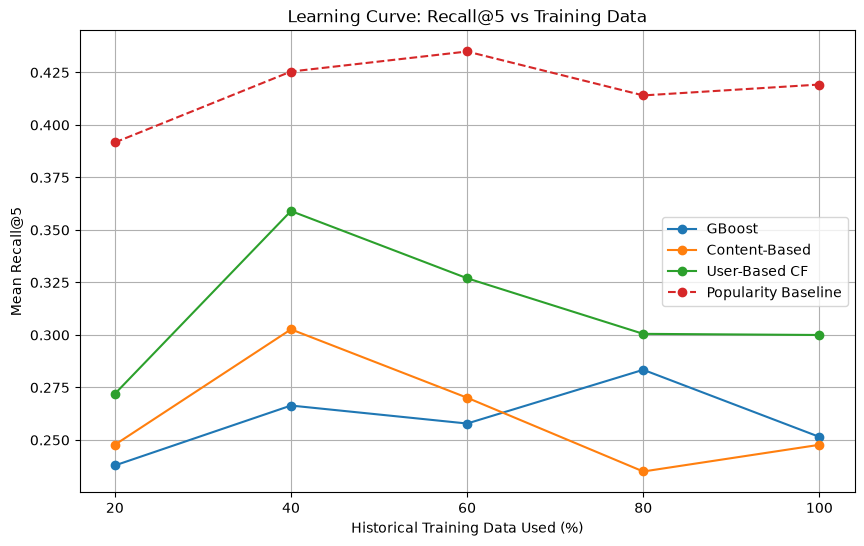

In [24]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.plot(
    learning_curve_df["Training Percentage"],
    learning_curve_df["GBoost Recall@5"],
    marker="o",
    label="GBoost"
)


plt.plot(
    learning_curve_df["Training Percentage"],
    learning_curve_df["Content-Based Recall@5"],
    marker="o",
    label="Content-Based"
)


plt.plot(
    learning_curve_df["Training Percentage"],
    learning_curve_df["User-Based Recall@5"],
    marker="o",
    label="User-Based CF"
)


plt.plot(
    learning_curve_df["Training Percentage"],
    learning_curve_df["Popularity Recall@5"],
    marker="o",
    linestyle="--",
    label="Popularity Baseline"
)


plt.xlabel("Historical Training Data Used (%)")

plt.ylabel("Mean Recall@5")

plt.title(
    "Learning Curve: Recall@5 vs Training Data"
)

plt.xticks(
    learning_curve_df["Training Percentage"]
)

plt.legend()

plt.grid(True)

plt.show()

In [26]:
# ============================================================
# LONG-TAIL RECALL LEARNING CURVE
#
# INCLUDED MODELS:
#   1. GBoost
#   2. Content-Based
#   3. User-Based CF
#   4. Popularity Baseline
#
# EXCLUDED:
#   - Item-Item CF
#
# IMPORTANT:
# The models themselves are NOT modified.
#
# The only experimental variable is the amount of historical
# training data used:
#
# 20% -> 40% -> 60% -> 80% -> 100%
# ============================================================


TRAIN_FRACTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]

K = 5
TOP_N = 5

learning_curve_longtail_rows = []


# ============================================================
# SORT HISTORICAL TRAINING DATA CHRONOLOGICALLY
# ============================================================

df_train_ordered = (
    df_train_pr
    .sort_values("Purchase Date")
    .copy()
)


# ============================================================
# RUN LEARNING CURVE EXPERIMENTS
# ============================================================

for fraction in TRAIN_FRACTIONS:

    print("\n" + "=" * 70)

    print(
        f"LONG-TAIL EXPERIMENT: "
        f"{int(fraction * 100)}% TRAINING DATA"
    )

    print("=" * 70)


    # ========================================================
    # CREATE TRAINING SUBSET
    #
    # THIS IS THE ONLY THING THAT CHANGES BETWEEN EXPERIMENTS
    # ========================================================

    train_end = int(
        len(df_train_ordered) * fraction
    )

    df_train_subset = (
        df_train_ordered
        .iloc[:train_end]
        .copy()
    )


    print(
        f"\nTraining rows: "
        f"{len(df_train_subset):,}"
    )

    print(
        f"Training customers: "
        f"{df_train_subset['Customer ID'].nunique():,}"
    )


    # ========================================================
    # MODEL 1 — GBOOST
    #
    # Existing model unchanged
    # ========================================================

    (
        results_gboost_lc,
        _,
        _
    ) = backtest_gboost_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        k=K
    )


    # ========================================================
    # MODEL 2 — CONTENT-BASED
    #
    # Existing model unchanged
    # ========================================================

    (
        results_content_lc,
        _,
        _
    ) = backtest_content_based_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        top_n=TOP_N,
        k=K
    )


    # ========================================================
    # MODEL 3 — USER-BASED CF
    #
    # Existing model unchanged
    # ========================================================

    train_seasons_lc = (
        df_train_subset["season"]
        .dropna()
        .unique()
    )


    # Customers that exist in both:
    # - current training subset
    # - fixed future evaluation data

    scoring_customers = np.intersect1d(

        df_train_subset[
            "Customer ID"
        ].unique(),

        df_future_pr[
            "Customer ID"
        ].unique()
    )


    (
        results_user_lc,
        _,
        _
    ) = backtest_recommender_pr(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        train_seasons=train_seasons_lc,
        k=K
    )


    # ========================================================
    # MODEL 4 — POPULARITY BASELINE
    #
    # Existing model unchanged
    # ========================================================

    (
        results_popularity_lc,
        _
    ) = backtest_popularity_churn_reactivation(

        df_train=df_train_subset,
        df_recent=df_recent_pr,
        df_future=df_future_pr,
        k=K
    )


    # ========================================================
    # CALCULATE ALL METRICS
    #
    # The existing metric function is unchanged.
    # ========================================================

    gboost_metrics = (
        calculate_all_ranking_and_long_tail_metrics(

            results_gboost_lc,
            df_train_subset,
            k=K
        )
    )


    content_metrics = (
        calculate_all_ranking_and_long_tail_metrics(

            results_content_lc,
            df_train_subset,
            k=K
        )
    )


    user_metrics = (
        calculate_all_ranking_and_long_tail_metrics(

            results_user_lc,
            df_train_subset,
            k=K
        )
    )


    popularity_metrics = (
        calculate_all_ranking_and_long_tail_metrics(

            results_popularity_lc,
            df_train_subset,
            k=K
        )
    )


    # ========================================================
    # STORE LONG-TAIL RECALL RESULTS
    #
    # IMPORTANT:
    # The correct metric key is:
    #
    # "Long-tail Recall"
    #
    # with lowercase "tail".
    # ========================================================

    learning_curve_longtail_rows.append({

        "Training Percentage":
            fraction * 100,

        "Training Rows":
            len(df_train_subset),

        "Training Customers":
            df_train_subset[
                "Customer ID"
            ].nunique(),

        "GBoost Long-tail Recall@5":
            gboost_metrics[
                "Long-tail Recall"
            ],

        "Content-Based Long-tail Recall@5":
            content_metrics[
                "Long-tail Recall"
            ],

        "User-Based Long-tail Recall@5":
            user_metrics[
                "Long-tail Recall"
            ],

        "Popularity Long-tail Recall@5":
            popularity_metrics[
                "Long-tail Recall"
            ]

    })


    # ========================================================
    # PRINT RESULTS FOR CURRENT EXPERIMENT
    # ========================================================

    print("\nLONG-TAIL RECALL RESULTS")

    print(
        f"GBoost Long-tail Recall@{K}: "
        f"{gboost_metrics['Long-tail Recall']:.4f}"
    )

    print(
        f"Content-Based Long-tail Recall@{K}: "
        f"{content_metrics['Long-tail Recall']:.4f}"
    )

    print(
        f"User-Based Long-tail Recall@{K}: "
        f"{user_metrics['Long-tail Recall']:.4f}"
    )

    print(
        f"Popularity Long-tail Recall@{K}: "
        f"{popularity_metrics['Long-tail Recall']:.4f}"
    )


# ============================================================
# CREATE FINAL LEARNING CURVE DATAFRAME
# ============================================================

learning_curve_longtail_df = pd.DataFrame(
    learning_curve_longtail_rows
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

learning_curve_longtail_df


LONG-TAIL EXPERIMENT: 20% TRAINING DATA

Training rows: 527
Training customers: 486
Possible churn customers: 168
Customers with a GBoost prediction available: 168
Customers who returned and were evaluated: 110
Precision@5: 0.0727
Recall@5: 0.2379
HitRate@5: 0.3273

Predicted category distribution (evaluated churn customers):
predicted_category
Footwear       53
Clothing       35
Accessories    22
Name: count, dtype: int64
Possible churn customers: 168
Customers who returned and were evaluated: 110
Precision@5: 0.0758
Recall@5: 0.2477
HitRate@5: 0.3636
Possible churn customers: 168
Customers who returned and were evaluated: 110
Average sparsity across training seasons: 0.9549
Precision@5: 0.0823
Recall@5: 0.2720
HitRate@5: 0.3818
Possible churn customers: 168
Customers who returned and were evaluated: 110
Top-5 popular items (df_recent): ['Kurta', 'Running Shoes', 'Sneakers', 'Saree', 'Jacket']
Precision@5: 0.1145
Recall@5: 0.3917
HitRate@5: 0.5364

LONG-TAIL RECALL RESULTS
GBoost Lon

,Training Percentage,Training Rows,Training Customers,GBoost Long-tail Recall@5,Content-Based Long-tail Recall@5,User-Based Long-tail Recall@5,Popularity Long-tail Recall@5
0,20.0,527,486,0.177305,0.134752,0.209220,0.0
1,40.0,1055,924,0.174603,0.142857,0.206349,0.0
2,60.0,1582,1286,0.099291,0.090426,0.157801,0.0
3,80.0,2110,1595,0.179790,0.073491,0.183727,0.0
4,100.0,2638,1865,0.092742,0.129032,0.159946,0.0


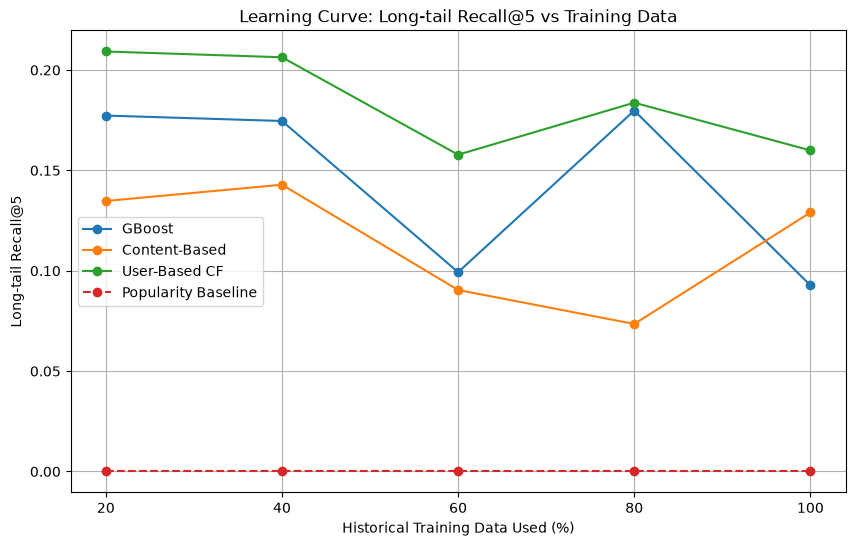

In [27]:



plt.figure(figsize=(10, 6))


# GBOOST

plt.plot(
    learning_curve_longtail_df[
        "Training Percentage"
    ],
    learning_curve_longtail_df[
        "GBoost Long-tail Recall@5"
    ],
    marker="o",
    label="GBoost"
)


# CONTENT-BASED

plt.plot(
    learning_curve_longtail_df[
        "Training Percentage"
    ],
    learning_curve_longtail_df[
        "Content-Based Long-tail Recall@5"
    ],
    marker="o",
    label="Content-Based"
)


# USER-BASED CF

plt.plot(
    learning_curve_longtail_df[
        "Training Percentage"
    ],
    learning_curve_longtail_df[
        "User-Based Long-tail Recall@5"
    ],
    marker="o",
    label="User-Based CF"
)


# POPULARITY BASELINE

plt.plot(
    learning_curve_longtail_df[
        "Training Percentage"
    ],
    learning_curve_longtail_df[
        "Popularity Long-tail Recall@5"
    ],
    marker="o",
    linestyle="--",
    label="Popularity Baseline"
)


# LABELS

plt.xlabel(
    "Historical Training Data Used (%)"
)

plt.ylabel(
    "Long-tail Recall@5"
)

plt.title(
    "Learning Curve: Long-tail Recall@5 vs Training Data"
)


plt.xticks(
    learning_curve_longtail_df[
        "Training Percentage"
    ]
)


plt.legend()

plt.grid(True)

plt.show()